In [1]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/subhasishchoudhury26/paysim/PS_20174392719_1491204439457_log.csv


In [3]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/subhasishchoudhury26/paysim/PS_20174392719_1491204439457_log.csv",
    nrows=50000
)

print("Shape:", df.shape)
df.head()

Shape: (50000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            50000 non-null  int64  
 1   type            50000 non-null  object 
 2   amount          50000 non-null  float64
 3   nameOrig        50000 non-null  object 
 4   oldbalanceOrg   50000 non-null  float64
 5   newbalanceOrig  50000 non-null  float64
 6   nameDest        50000 non-null  object 
 7   oldbalanceDest  50000 non-null  float64
 8   newbalanceDest  50000 non-null  float64
 9   isFraud         50000 non-null  int64  
 10  isFlaggedFraud  50000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 4.2+ MB


In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
df['isFraud'].value_counts()

isFraud
0    49900
1      100
Name: count, dtype: int64

In [7]:
fraud_percentage = (df['isFraud'].sum() / len(df)) * 100

print(f"Fraud Percentage: {fraud_percentage:.2f}%")

Fraud Percentage: 0.20%


In [8]:
df.groupby('type')['isFraud'].sum()

type
CASH_IN      0
CASH_OUT    51
DEBIT        0
PAYMENT      0
TRANSFER    49
Name: isFraud, dtype: int64

In [9]:
df['type'].value_counts()

type
PAYMENT     21912
CASH_OUT    13756
CASH_IN      8992
TRANSFER     4700
DEBIT         640
Name: count, dtype: int64

In [10]:
def calculate_risk(row):
    
    score = 0
    
    # Large transaction
    if row['amount'] > 200000:
        score += 40
        
    # Transfer transactions
    if row['type'] == 'TRANSFER':
        score += 30
        
    # Cash Out transactions
    if row['type'] == 'CASH_OUT':
        score += 20
        
    # Flagged fraud
    if row['isFlaggedFraud'] == 1:
        score += 50
        
    return score

In [11]:
df['Risk_Score'] = df.apply(calculate_risk, axis=1)

df[['type','amount','Risk_Score']].head()

,type,amount,Risk_Score
0,PAYMENT,9839.64,0
1,PAYMENT,1864.28,0
2,TRANSFER,181.00,30
3,CASH_OUT,181.00,20
4,PAYMENT,11668.14,0


In [12]:
def risk_level(score):
    
    if score >= 60:
        return "High"
    
    elif score >= 30:
        return "Medium"
    
    else:
        return "Low"

In [13]:
df['Risk_Level'] = df['Risk_Score'].apply(risk_level)

df[['Risk_Score','Risk_Level']].head()

,Risk_Score,Risk_Level
0,0,Low
1,0,Low
2,30,Medium
3,20,Low
4,0,Low


In [14]:
df['Risk_Level'].value_counts()

Risk_Level
Low       37059
High       8765
Medium     4176
Name: count, dtype: int64

In [15]:
pd.crosstab(
    df['Risk_Level'],
    df['isFraud']
)

isFraud,0,1
Risk_Level,,
High,8735,30
Low,37023,36
Medium,4142,34


In [16]:
df.sort_values(
    by='Risk_Score',
    ascending=False
)[['type','amount','Risk_Score','Risk_Level','isFraud']].head(10)

,type,amount,Risk_Score,Risk_Level,isFraud
49968,TRANSFER,1952267.42,70,High,0
24,TRANSFER,311685.89,70,High,0
49984,TRANSFER,1868673.91,70,High,0
19,TRANSFER,215310.30,70,High,0
49976,TRANSFER,1551217.35,70,High,0
49975,TRANSFER,450073.94,70,High,0
21537,TRANSFER,213705.41,70,High,0
21545,TRANSFER,1530181.35,70,High,0
21550,TRANSFER,473531.89,70,High,0
38030,TRANSFER,1025370.69,70,High,0


In [17]:
def calculate_risk_v2(row):

    score = 0

    # Large transaction
    if row['amount'] > 200000:
        score += 40

    # Very large transaction
    if row['amount'] > 500000:
        score += 30

    # Transfer transactions
    if row['type'] == 'TRANSFER':
        score += 30

    # Cash Out transactions
    if row['type'] == 'CASH_OUT':
        score += 20

    # Sender account emptied
    if row['newbalanceOrig'] == 0:
        score += 20

    # Flagged fraud
    if row['isFlaggedFraud'] == 1:
        score += 50

    return score

In [18]:
df['Risk_Score_V2'] = df.apply(calculate_risk_v2, axis=1)

df[['type','amount','Risk_Score_V2']].head()

,type,amount,Risk_Score_V2
0,PAYMENT,9839.64,0
1,PAYMENT,1864.28,0
2,TRANSFER,181.00,50
3,CASH_OUT,181.00,40
4,PAYMENT,11668.14,0


In [19]:
df['Risk_Level_V2'] = df['Risk_Score_V2'].apply(risk_level)

df[['Risk_Score_V2','Risk_Level_V2']].head()

,Risk_Score_V2,Risk_Level_V2
0,0,Low
1,0,Low
2,50,Medium
3,40,Medium
4,0,Low


In [20]:
df['Risk_Level_V2'].value_counts()

Risk_Level_V2
Low       29724
Medium    11308
High       8968
Name: count, dtype: int64

In [21]:
pd.crosstab(
    df['Risk_Level_V2'],
    df['isFraud']
)

isFraud,0,1
Risk_Level_V2,,
High,8938,30
Low,29724,0
Medium,11238,70


In [22]:
df['Suspicious_Alert'] = df['Risk_Level_V2'].isin(['Medium', 'High'])

df[['Risk_Level_V2','Suspicious_Alert']].head()

,Risk_Level_V2,Suspicious_Alert
0,Low,False
1,Low,False
2,Medium,True
3,Medium,True
4,Low,False


In [23]:
df['Suspicious_Alert'].value_counts()

Suspicious_Alert
False    29724
True     20276
Name: count, dtype: int64

In [24]:
import matplotlib.pyplot as plt

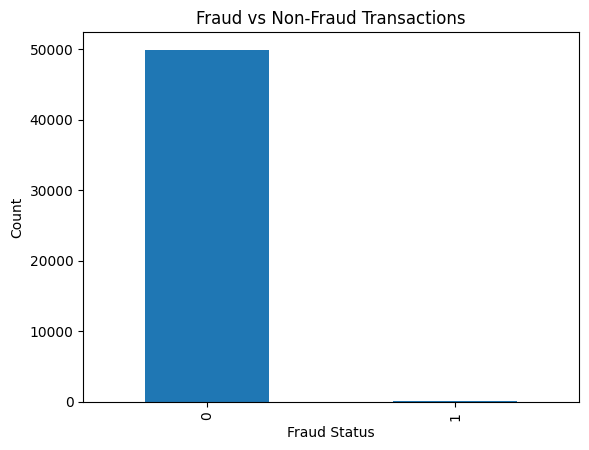

In [25]:
df['isFraud'].value_counts().plot(
    kind='bar'
)

plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Fraud Status')
plt.ylabel('Count')

plt.show()

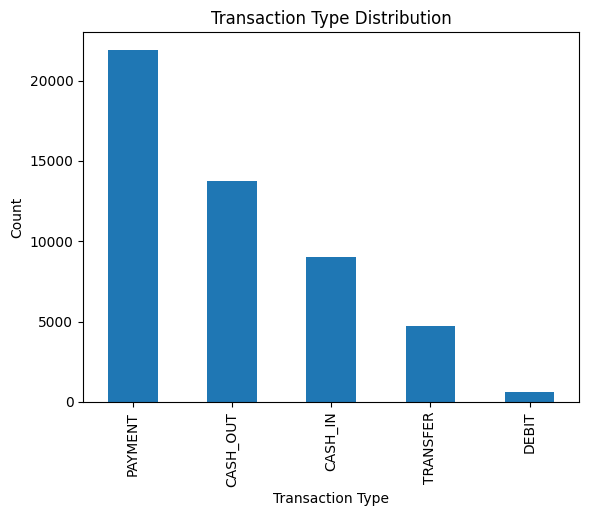

In [26]:
df['type'].value_counts().plot(
    kind='bar'
)

plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')

plt.show()

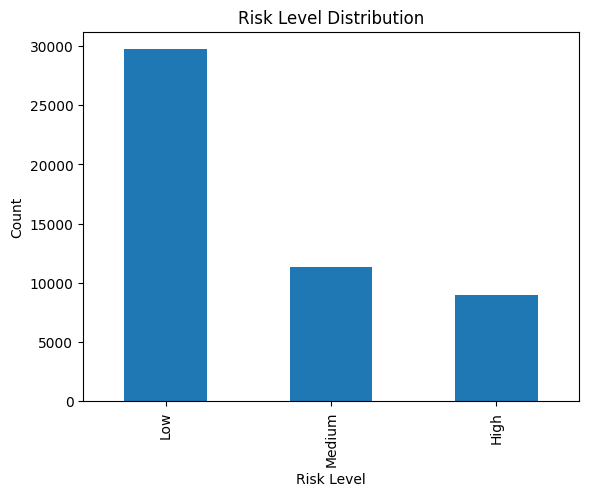

In [27]:
df['Risk_Level_V2'].value_counts().plot(
    kind='bar'
)

plt.title('Risk Level Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Count')

plt.show()

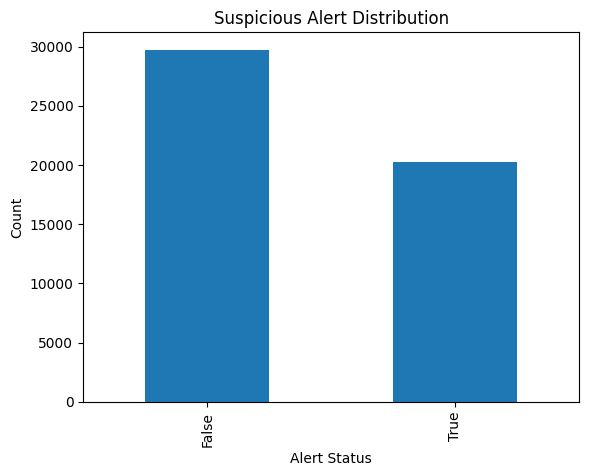

In [28]:
df['Suspicious_Alert'].value_counts().plot(
    kind='bar'
)

plt.title('Suspicious Alert Distribution')
plt.xlabel('Alert Status')
plt.ylabel('Count')

plt.show()

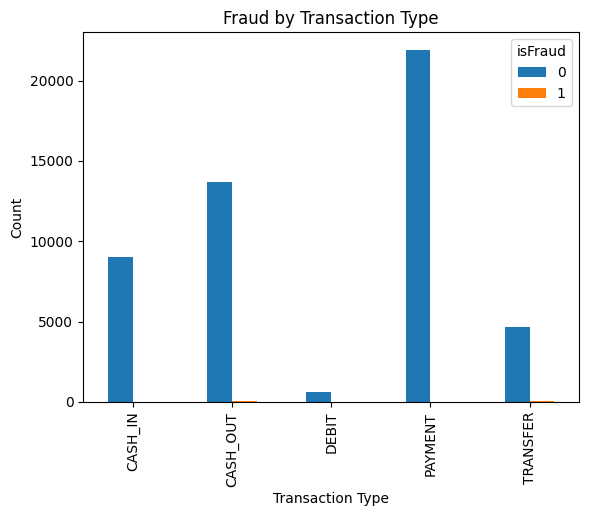

In [29]:
fraud_by_type = pd.crosstab(
    df['type'],
    df['isFraud']
)

fraud_by_type.plot(kind='bar')

plt.title('Fraud by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')

plt.show()

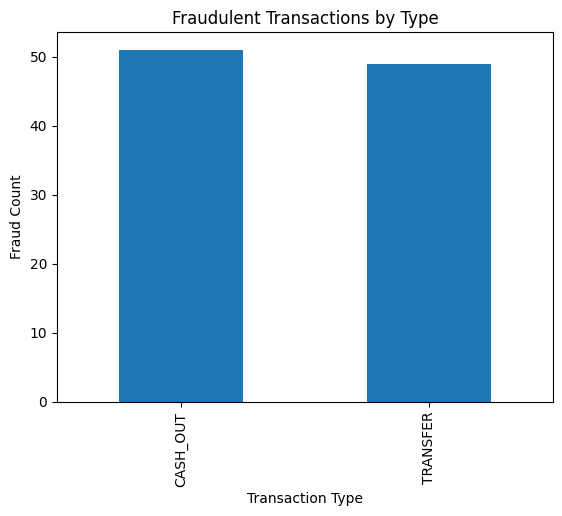

In [30]:
fraud_only = df[df['isFraud'] == 1]

fraud_only['type'].value_counts().plot(
    kind='bar'
)

plt.title('Fraudulent Transactions by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Count')

plt.show()

In [31]:
# Total Transactions
total_transactions = len(df)

# Fraud Transactions
fraud_transactions = df['isFraud'].sum()

# Fraud Rate
fraud_rate = (fraud_transactions / total_transactions) * 100

# High Risk Transactions
high_risk = (df['Risk_Level_V2'] == 'High').sum()

# Suspicious Alerts
alerts = df['Suspicious_Alert'].sum()

print("Total Transactions:", total_transactions)
print("Fraud Transactions:", fraud_transactions)
print("Fraud Rate:", round(fraud_rate,2), "%")
print("High Risk Transactions:", high_risk)
print("Suspicious Alerts:", alerts)

Total Transactions: 50000
Fraud Transactions: 100
Fraud Rate: 0.2 %
High Risk Transactions: 8968
Suspicious Alerts: 20276


In [32]:
summary = pd.DataFrame({
    'Metric':[
        'Total Transactions',
        'Fraud Transactions',
        'Fraud Rate (%)',
        'High Risk Transactions',
        'Suspicious Alerts'
    ],
    'Value':[
        total_transactions,
        fraud_transactions,
        round(fraud_rate,2),
        high_risk,
        alerts
    ]
})

summary

,Metric,Value
0,Total Transactions,50000.0
1,Fraud Transactions,100.0
2,Fraud Rate (%),0.2
3,High Risk Transactions,8968.0
4,Suspicious Alerts,20276.0


In [33]:
top_risk = df.sort_values(
    by='Risk_Score_V2',
    ascending=False
)[[
    'type',
    'amount',
    'Risk_Score_V2',
    'Risk_Level_V2',
    'isFraud'
]]

top_risk.head(50)

,type,amount,Risk_Score_V2,Risk_Level_V2,isFraud
49984,TRANSFER,1868673.91,120,High,0
20143,TRANSFER,1645104.90,120,High,0
20095,TRANSFER,500301.57,120,High,0
49928,TRANSFER,660756.97,120,High,0
49930,TRANSFER,691120.65,120,High,0
49931,TRANSFER,731328.81,120,High,0
49939,TRANSFER,778456.84,120,High,0
20229,TRANSFER,2246018.57,120,High,0
20060,TRANSFER,1327566.28,120,High,0
20310,TRANSFER,780886.93,120,High,0


In [34]:
high_risk_df = df[df['Risk_Level_V2'] == 'High']

high_risk_df['isFraud'].value_counts()

isFraud
0    8938
1      30
Name: count, dtype: int64

In [35]:
high_risk_fraud_rate = (
    high_risk_df['isFraud'].sum()
    /
    len(high_risk_df)
) * 100

print(
    f"Fraud Rate within High Risk Transactions: {high_risk_fraud_rate:.2f}%"
)

Fraud Rate within High Risk Transactions: 0.33%


In [36]:
df.to_csv('AML_Final_Dashboard_Data.csv', index=False)

In [37]:
import os

os.listdir('/kaggle/working')

['__notebook__.ipynb', 'AML_Final_Dashboard_Data.csv']

In [38]:
from IPython.display import FileLink

FileLink('/kaggle/working/AML_Final_Dashboard_Data.csv')

/kaggle/working/AML_Final_Dashboard_Data.csv